# 01 — Exploratory Data Analysis (EDA)

Notebook ini digunakan untuk memahami **`aligned_daily.csv`** sebelum eksperimen machine learning.

Analisis yang dilakukan:
1. Struktur dan kualitas data
2. Distribusi target `direction`
3. Pergerakan JISDOR dan `log_return`
4. Distribusi jumlah berita (`n_news`)
5. Distribusi `mean_relevance`
6. Hubungan fitur berita dengan arah kurs
7. Missing value
8. Pemeriksaan tanggal
9. **Temporal split** menjadi Train–Validation–Test

> **Catatan:** karena data merupakan time-series, split dilakukan berdasarkan urutan waktu, bukan random. Random split dapat menyebabkan data dari masa depan masuk ke training dan membuat evaluasi terlalu optimistis (temporal leakage).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Jalankan notebook dari root repository.
DATA_PATH = Path("../data/processed/aligned_daily.csv")

if not DATA_PATH.exists():
    # Fallback jika notebook dijalankan dari root repository.
    DATA_PATH = Path("data/processed/aligned_daily.csv")

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (1202, 23)


,date,kurs,prev_kurs,prev_date,gap_days,delta,log_return,direction,realized_vol,lag1_log_return,...,n_news,mean_relevance,max_relevance,mean_tokens,pct_offhours,mean_lm_polarity,lm_positive_sum,lm_negative_sum,text_norm_concat,window_hours
0,2021-09-01,14284.0,NaN,NaN,NaN,NaN,NaN,flat,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,24.0
1,2021-09-02,14281.0,14284.0,2021-09-01,1.0,-3.0,-0.000210,flat,NaN,NaN,...,2,7.0,10.0,609.0,0.5,-0.632479,13.0,53.0,biden place u.s support ukraine front center z...,24.0
2,2021-09-03,14261.0,14281.0,2021-09-02,1.0,-20.0,-0.001401,down,NaN,-0.000210,...,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,24.0
3,2021-09-06,14239.0,14261.0,2021-09-03,3.0,-22.0,-0.001544,down,NaN,-0.001401,...,1,9.0,9.0,532.0,1.0,-0.315789,13.0,25.0,afghanistan pullout sparks eu calls military m...,72.0
4,2021-09-07,14195.0,14239.0,2021-09-06,1.0,-44.0,-0.003095,down,NaN,-0.001544,...,1,2.0,2.0,675.0,1.0,-0.176471,7.0,10.0,chinese stocks briefly surge 30% investors bet...,24.0


## 1. Struktur dan kualitas data

In [2]:
print("Kolom:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nRingkasan numerik:")
display(df.describe(include="all").T)

Kolom:
['date', 'kurs', 'prev_kurs', 'prev_date', 'gap_days', 'delta', 'log_return', 'direction', 'realized_vol', 'lag1_log_return', 'lag2_log_return', 'lag3_log_return', 'lag1_realized_vol', 'n_news', 'mean_relevance', 'max_relevance', 'mean_tokens', 'pct_offhours', 'mean_lm_polarity', 'lm_positive_sum', 'lm_negative_sum', 'text_norm_concat', 'window_hours']

Data types:


date                 datetime64[us]
kurs                        float64
prev_kurs                   float64
prev_date                       str
gap_days                    float64
delta                       float64
log_return                  float64
direction                       str
realized_vol                float64
lag1_log_return             float64
lag2_log_return             float64
lag3_log_return             float64
lag1_realized_vol           float64
n_news                        int64
mean_relevance              float64
max_relevance               float64
mean_tokens                 float64
pct_offhours                float64
mean_lm_polarity            float64
lm_positive_sum             float64
lm_negative_sum             float64
text_norm_concat                str
window_hours                float64
dtype: object


Ringkasan numerik:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1202,NaN,NaN,NaN,2024-02-21 11:03:41.630615,2021-09-01 00:00:00,2022-11-16 06:00:00,2024-02-14 00:00:00,2025-05-31 18:00:00,2026-09-01 00:00:00,NaN
kurs,1202.0,NaN,NaN,NaN,15741.955907,14080.0,14984.0,15650.5,16384.75,18171.0,976.127715
prev_kurs,1201.0,NaN,NaN,NaN,15740.303081,14080.0,14984.0,15649.0,16384.0,18171.0,974.850212
prev_date,1201,1201,2021-09-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gap_days,1201.0,NaN,NaN,NaN,1.5204,1.0,1.0,1.0,1.0,12.0,1.089247
delta,1201.0,NaN,NaN,NaN,2.866778,-221.0,-23.0,6.0,33.0,303.0,52.839763
log_return,1201.0,NaN,NaN,NaN,0.00018,-0.014112,-0.001479,0.000385,0.002097,0.018909,0.003335
direction,1202,3,up,571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
realized_vol,1197.0,NaN,NaN,NaN,0.002886,0.000255,0.001778,0.002613,0.003577,0.01001,0.001625
lag1_log_return,1200.0,NaN,NaN,NaN,0.000181,-0.014112,-0.001479,0.000386,0.002098,0.018909,0.003336


## 2. Distribusi target `direction`

,count
direction,
up,571
down,435
flat,196


,percentage
direction,
up,47.50
down,36.19
flat,16.31


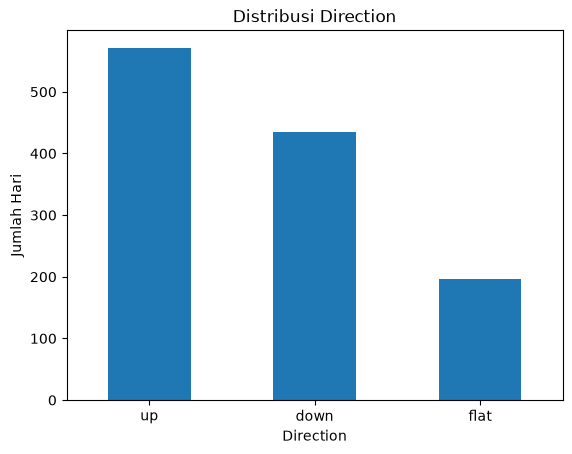

In [3]:
direction_counts = df["direction"].value_counts(dropna=False)

display(direction_counts.to_frame("count"))
display((direction_counts / len(df) * 100).round(2).to_frame("percentage"))

ax = direction_counts.plot(kind="bar")
ax.set_title("Distribusi Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Jumlah Hari")
plt.xticks(rotation=0)
plt.show()

## 3. Pergerakan JISDOR dan `log_return`

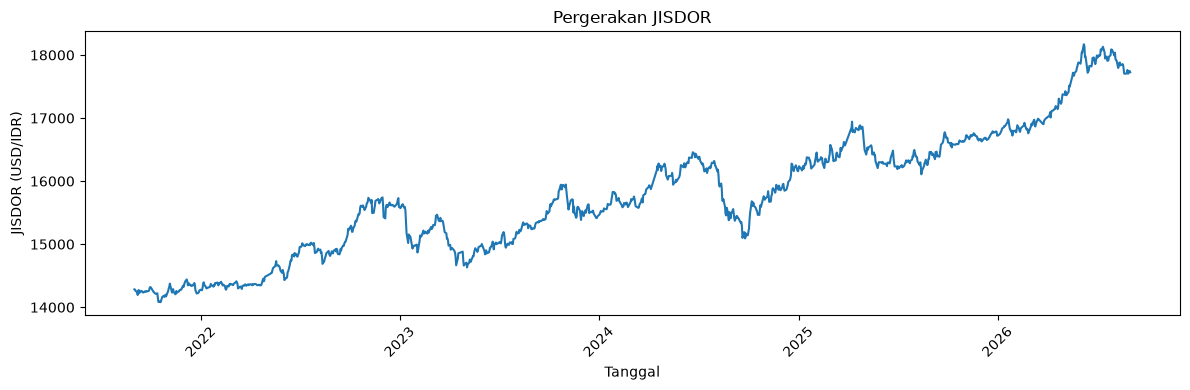

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["kurs"])
ax.set_title("Pergerakan JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("JISDOR (USD/IDR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

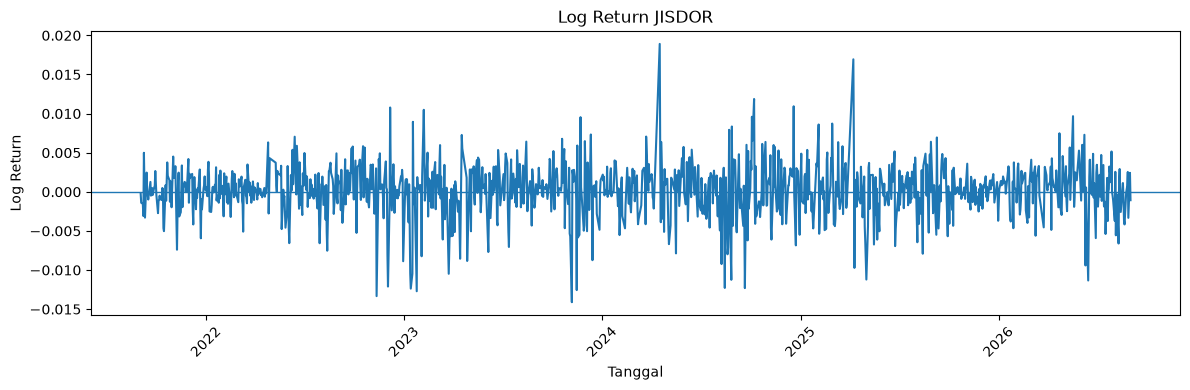

count    1201.000000
mean        0.000180
std         0.003335
min        -0.014112
25%        -0.001479
50%         0.000385
75%         0.002097
max         0.018909
Name: log_return, dtype: float64

In [5]:
log_return = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.loc[df["log_return"].notna(), "date"], log_return)
ax.axhline(0, linewidth=1)
ax.set_title("Log Return JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Log Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(df["log_return"].describe())

## 4. Distribusi jumlah berita (`n_news`)

,n_news
count,1202.000000
mean,5.002496
std,6.795269
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,139.000000


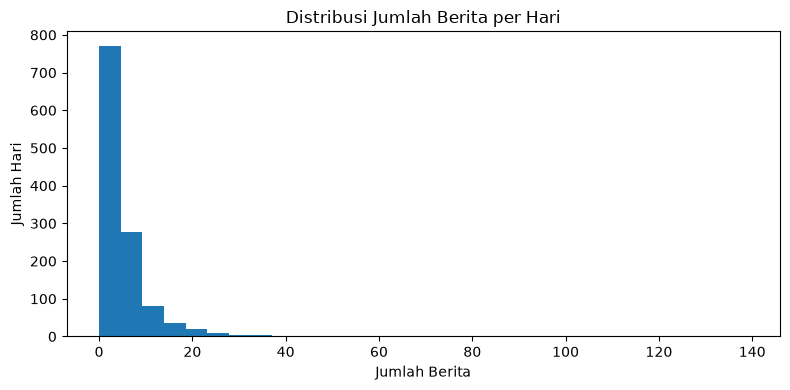

Hari tanpa berita: 94
Hari dengan berita: 1108


In [6]:
display(df["n_news"].describe().to_frame("n_news"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["n_news"].dropna(), bins=30)
ax.set_title("Distribusi Jumlah Berita per Hari")
ax.set_xlabel("Jumlah Berita")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

print("Hari tanpa berita:", (df["n_news"] == 0).sum())
print("Hari dengan berita:", (df["n_news"] > 0).sum())

## 5. Distribusi `mean_relevance`

,mean_relevance
count,1108.000000
mean,7.253352
std,2.838770
min,2.000000
25%,5.087413
50%,7.000000
75%,9.000000
max,21.000000


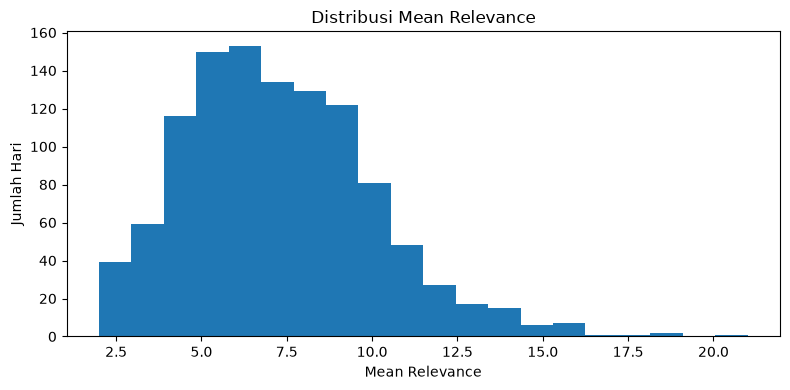

In [7]:
display(df["mean_relevance"].describe().to_frame("mean_relevance"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["mean_relevance"].dropna(), bins=20)
ax.set_title("Distribusi Mean Relevance")
ax.set_xlabel("Mean Relevance")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

## 6. Hubungan fitur berita dengan arah kurs

In [8]:
# Ringkasan fitur berita berdasarkan direction
news_by_direction = (
    df.groupby("direction", dropna=False)[["n_news", "mean_relevance", "max_relevance", "mean_tokens", "pct_offhours"]]
      .agg(["count", "mean", "median"])
)

display(news_by_direction)

n_news                  mean_relevance                      \
           count      mean median          count      mean    median   
direction                                                              
down         435  5.142529    3.0            406  7.297130  7.000000   
flat         196  4.515306    3.0            174  7.245489  7.045455   
up           571  5.063047    3.0            528  7.222281  7.000000   

          max_relevance                   mean_tokens                          \
                  count       mean median       count        mean      median   
direction                                                                       
down                406  11.135468   12.0         406  566.539487  571.187500   
flat                174  10.988506   11.0         174  567.375119  575.500000   
up                  528  10.857955   11.0         528  569.724554  574.572727   

          pct_offhours                      
                 count      mean    median  
direction                                   
down               406  0.840126  1.000000  
flat               174  0.817862  0.908333  
up                 528  0.816085  0.959936

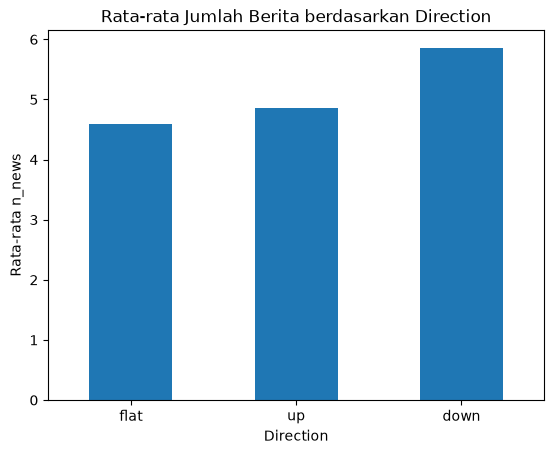

In [10]:
# Rata-rata jumlah berita per direction
mean_news = df.groupby("direction")["n_news"].mean().sort_values()

ax = mean_news.plot(kind="bar")
ax.set_title("Rata-rata Jumlah Berita berdasarkan Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Rata-rata n_news")
plt.xticks(rotation=0)
plt.show()

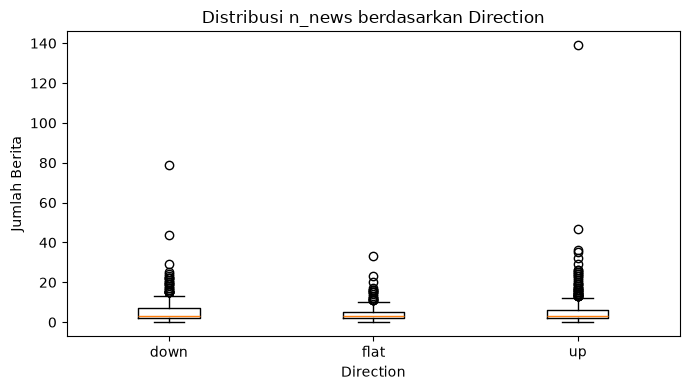

In [9]:
# Boxplot jumlah berita menurut direction
groups = []
labels = []

for label, group in df.groupby("direction"):
    groups.append(group["n_news"].dropna())
    labels.append(label)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(groups, tick_labels=labels)
ax.set_title("Distribusi n_news berdasarkan Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Jumlah Berita")
plt.tight_layout()
plt.show()

### Catatan interpretasi

Bagian ini hanya mengeksplorasi **asosiasi/pola awal**. Perbedaan jumlah berita atau sentiment/relevance antar-kelas **belum membuktikan hubungan kausal** dan belum berarti fitur tersebut akan meningkatkan performa model.

## 7. Missing value

In [10]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("missing_count", ascending=False))

,missing_count,missing_percentage
pct_offhours,94,7.82
mean_tokens,94,7.82
max_relevance,94,7.82
mean_relevance,94,7.82
mean_lm_polarity,94,7.82
text_norm_concat,94,7.82
lag1_realized_vol,6,0.50
realized_vol,5,0.42
lag3_log_return,4,0.33
lag2_log_return,3,0.25


## 8. Pemeriksaan tanggal dan potensi masalah temporal

In [11]:
# Cek duplikasi tanggal
print("Jumlah tanggal duplikat:", df["date"].duplicated().sum())

# Cek tanggal weekend
weekend_rows = df[df["date"].dt.dayofweek >= 5][["date", "kurs", "direction"]]
print("Jumlah row weekend:", len(weekend_rows))

if len(weekend_rows) > 0:
    display(weekend_rows.head(20))

# Cek urutan waktu
print("Tanggal minimum:", df["date"].min().date())
print("Tanggal maksimum:", df["date"].max().date())
print("Urutan tanggal sudah ascending:", df["date"].is_monotonic_increasing)

Jumlah tanggal duplikat: 0
Jumlah row weekend: 0
Tanggal minimum: 2021-09-01
Tanggal maksimum: 2026-09-01
Urutan tanggal sudah ascending: True


> **Penting:** bila pemeriksaan di atas menemukan tanggal non-business day pada data JISDOR, jangan langsung menghapusnya. Periksa kembali proses alignment/target terlebih dahulu karena kesalahan tanggal dapat memengaruhi eksperimen secara keseluruhan.

## 9. Temporal Train–Validation–Test Split

In [12]:
# Split kronologis 70% / 15% / 15%.
# Tidak menggunakan random split karena data memiliki urutan waktu.

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("TRAIN")
print(train["date"].min().date(), "→", train["date"].max().date(), "|", len(train), "rows")

print("\nVALIDATION")
print(validation["date"].min().date(), "→", validation["date"].max().date(), "|", len(validation), "rows")

print("\nTEST")
print(test["date"].min().date(), "→", test["date"].max().date(), "|", len(test), "rows")

TRAIN
2021-09-01 → 2025-02-18 | 841 rows

VALIDATION
2025-02-19 → 2025-11-21 | 180 rows

TEST
2025-11-24 → 2026-09-01 | 181 rows


In [13]:
# Simpan split untuk dipakai notebook/model berikutnya.
SPLIT_DIR = DATA_PATH.parent / "split"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train.to_csv(SPLIT_DIR / "train.csv", index=False)
validation.to_csv(SPLIT_DIR / "validation.csv", index=False)
test.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Split disimpan di:", SPLIT_DIR.resolve())

Split disimpan di: /Users/aliyajumarna/Documents/Nyimut-NLP-26/data/processed/split


In [14]:
# Cek distribusi target per split
split_summary = pd.DataFrame({
    "train": train["direction"].value_counts(normalize=True),
    "validation": validation["direction"].value_counts(normalize=True),
    "test": test["direction"].value_counts(normalize=True),
}).fillna(0).round(3)

display(split_summary)

,train,validation,test
direction,,,
up,0.471,0.456,0.514
down,0.359,0.389,0.348
flat,0.170,0.156,0.138


## Output yang diharapkan

Setelah notebook dijalankan, kita harus punya:
- gambaran kualitas dan distribusi dataset,
- visualisasi JISDOR dan `log_return`,
- gambaran pola berita terhadap `direction`,
- daftar missing value,
- pengecekan tanggal/temporal alignment,
- `train.csv`, `validation.csv`, dan `test.csv`.

Notebook berikutnya baru digunakan untuk eksperimen model, dimulai dari **historical baseline** lalu dibandingkan dengan **TF-IDF/NLP baseline** dan **combined model**.